In [4]:
import time, csv, warnings
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", message=".*encountered in matmul.*", category=RuntimeWarning)

from core import make_data, loss, optimal
from opt import gd, sgd, hf, cost_to_eps, acc_at_budget

%matplotlib inline

In [ ]:
N, d   = 100, 20
kappas = np.logspace(0, 4, 9)
noises = [0.0, 0.1]

run_budget = 100_000

eps_val  = [1e-2, 1e-6]
cost_val = [1e2, 1e4]

eps_min = min(eps_val)
cg_tol  = 1e-8

assert max(cost_val) <= run_budget

color = {"HF": "#2a78d6", "GD": "#eb6834", "SGD": "#1baf7a"}
order = ["HF", "GD", "SGD"]
ink, muted, grid_c, surface = "#1a1a19", "#6b6b68", "#e4e4e1", "#fcfcfb"


In [ ]:
def eigen_range(X):
    ev = np.linalg.eigvalsh((X.T @ X) / X.shape[0])
    return ev[0], ev[-1]

def style(ax, title, xlab=True, ylab=None):
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_facecolor(surface)
    ax.set_title(title, fontsize=10, color=ink, pad=6, loc="left")
    if xlab: ax.set_xlabel("condition number  κ", fontsize=9, color=muted)
    if ylab: ax.set_ylabel(ylab, fontsize=9, color=muted)
    ax.grid(True, which="major", color=grid_c, linewidth=0.8, zorder=0)
    ax.grid(True, which="minor", color=grid_c, linewidth=0.4, alpha=0.5, zorder=0)
    ax.tick_params(colors=muted, labelsize=8)
    for s in ax.spines.values(): s.set_color(grid_c)

def method_handles():
    batch = next(st["batch"] for (_, _, m), st in runs.items() if m == "SGD")
    h = [plt.Line2D([], [], color=color[m], linewidth=2, marker="o", markersize=5,
                    markeredgecolor=surface, label=lbl)
         for m, lbl in [("HF", "HF (Newton+CG)"), ("GD", "GD (full batch)"),
                        ("SGD", f"SGD (batch={batch})")]]
    h.append(plt.Line2D([], [], color=muted, linestyle="none", marker="^",
                        markerfacecolor=surface, markeredgecolor=muted,
                        markersize=7, label=f"censored at C={run_budget:,}"))
    return h



In [ ]:
runs = {}

t_all = time.perf_counter()
for noise in noises:
    for kappa in kappas:
        X, y, _ = make_data(N, d, kappa, noise=noise)
        w_star, L_star = optimal(X, y)
        L0 = loss(np.zeros(d), X, y)
        lmin, lmax = eigen_range(X)
        lr_gd = 2.0 / (lmin + lmax)

        arms = {
            "HF":  (lambda: hf(X, y, budget=run_budget, eps_floor=eps_min,
                               L_star=L_star, cg_tol=cg_tol), np.nan),
            "GD":  (lambda: gd(X, y, lr_gd, budget=run_budget, eps_floor=eps_min,
                               L_star=L_star), lr_gd),
            "SGD": (lambda: sgd(X, y, budget=run_budget, eps_floor=eps_min,
                                L_star=L_star, lmax=lmax,
                                lmin=None if noise == 0.0 else lmin), None),
        }
        for name, (fn, lr) in arms.items():
            t0 = time.perf_counter()
            w, st = fn()
            st["seconds"] = time.perf_counter() - t0
            st.update(L0=L0, L_star=L_star,
                      w_err=np.linalg.norm(w - w_star) / max(np.linalg.norm(w_star), 1e-300))
            if lr is not None:
                st["lr"] = lr
            runs[(noise, kappa, name)] = st
            print(f"noise={noise} k={kappa:>9.1f} {name:>3} "
                  f"cost={st['cost']:>10.1f} floor={int(st['reached_floor'])} "
                  f"pts={len(st['trace']):>6d} {st['seconds']:>6.2f}s")

print(f"\ntotal {time.perf_counter() - t_all:.1f}s")

noise=0.0 k=      1.0  HF cost=       2.0 floor=1 pts=     3   0.00s
noise=0.0 k=      1.0  GD cost=       1.0 floor=1 pts=     2   0.00s
noise=0.0 k=      1.0 SGD cost=       5.0 floor=1 pts=     6   0.00s
noise=0.0 k=      3.2  HF cost=      15.0 floor=1 pts=    16   0.00s
noise=0.0 k=      3.2  GD cost=       9.0 floor=1 pts=    10   0.00s
noise=0.0 k=      3.2 SGD cost=       5.0 floor=1 pts=     6   0.00s
noise=0.0 k=     10.0  HF cost=      20.0 floor=1 pts=    21   0.00s
noise=0.0 k=     10.0  GD cost=      28.0 floor=1 pts=    29   0.00s
noise=0.0 k=     10.0 SGD cost=       6.0 floor=1 pts=     7   0.00s
noise=0.0 k=     31.6  HF cost=      22.0 floor=1 pts=    23   0.00s
noise=0.0 k=     31.6  GD cost=      92.0 floor=1 pts=    93   0.00s
noise=0.0 k=     31.6 SGD cost=      14.0 floor=1 pts=    15   0.00s
noise=0.0 k=    100.0  HF cost=      25.0 floor=1 pts=    26   0.00s
noise=0.0 k=    100.0  GD cost=     297.0 floor=1 pts=   298   0.00s
noise=0.0 k=    100.0 SGD cost=   

## Slice trace -> `results.csv`

In [4]:
rows = []
for (noise, kappa, m), st in runs.items():
    tr, L0, Ls = st["trace"], st["L0"], st["L_star"]
    for eps in eps_val:
        c = cost_to_eps(tr, L0, Ls, eps)
        rows.append({"noise": noise, "kappa": kappa, "method": m, "lr": st["lr"],
                     "readout": "cost_to_eps", "level": eps,
                     "value": c if c is not None else run_budget,
                     "censored": int(c is None),
                     "w_err": st["w_err"], "seconds": st["seconds"]})
    for C in cost_val:
        rows.append({"noise": noise, "kappa": kappa, "method": m, "lr": st["lr"],
                     "readout": "acc_at_C", "level": C,
                     "value": acc_at_budget(tr, L0, Ls, C),
                     "censored": 0,
                     "w_err": st["w_err"], "seconds": st["seconds"]})

with open("results.csv", "w", newline="") as f:
    wtr = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    wtr.writeheader(); wtr.writerows(rows)
print(f"wrote {len(rows)} rows -> results.csv")

wrote 324 rows -> results.csv


## Plot A — cost-to-eps (slice horizontal)

Berapa cost buat nyampe akurasi yang **sama**. Marker bolong + panah = censored
(kena `run_budget` tanpa pernah nyentuh `eps`), jadi titik itu adalah **batas bawah**.

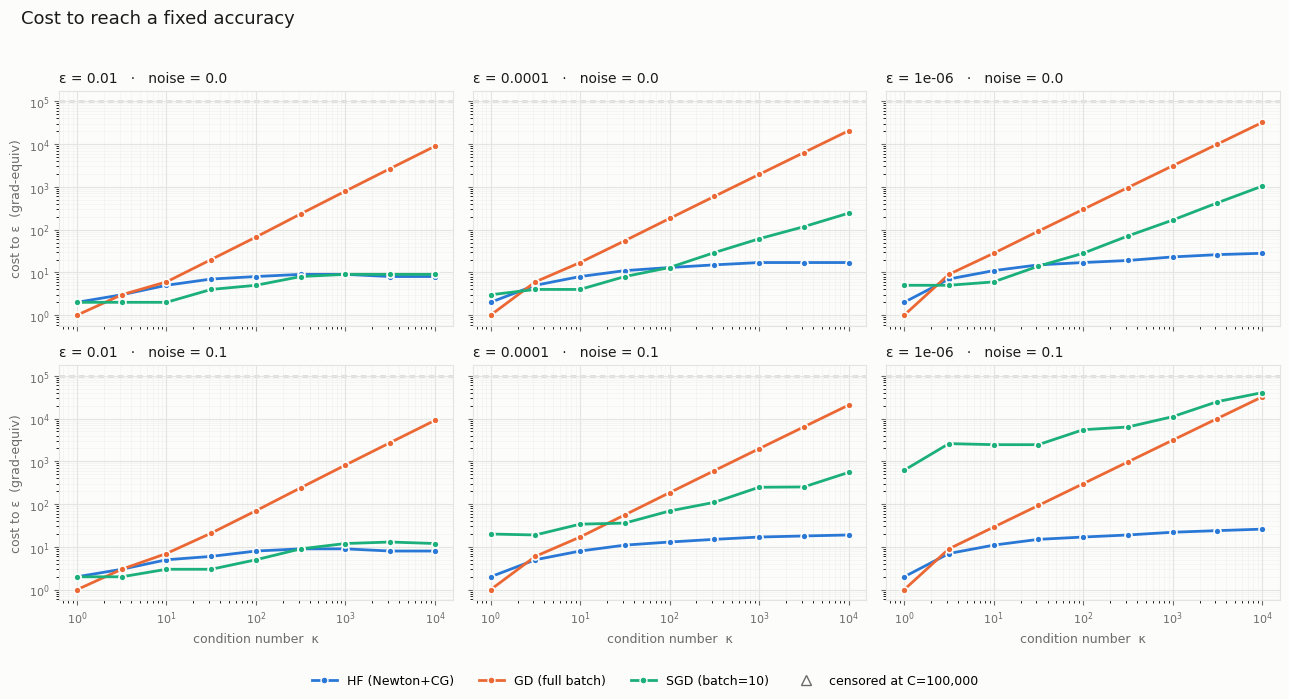

In [5]:
def series_cost(noise, m, eps):
    ks = sorted(kappas)
    v, cen = [], []
    for k in ks:
        st = runs[(noise, k, m)]
        c = cost_to_eps(st["trace"], st["L0"], st["L_star"], eps)
        cen.append(c is None)
        v.append(run_budget if c is None else c)
    return np.array(ks), np.array(v), np.array(cen)

fig, axes = plt.subplots(len(noises), len(eps_val), figsize=(13, 7),
                         sharex=True, sharey=True)
fig.patch.set_facecolor(surface)
for i, noise in enumerate(noises):
    for j, eps in enumerate(eps_val):
        ax = axes[i, j]
        for m in order:
            ks, v, cen = series_cost(noise, m, eps)
            ax.plot(ks, v, color=color[m], linewidth=2, zorder=3)
            ax.plot(ks[~cen], v[~cen], "o", color=color[m], markersize=5,
                    markeredgecolor=surface, markeredgewidth=1.2, zorder=4)
            if cen.any():
                ax.plot(ks[cen], v[cen], "^", color=surface, markersize=7,
                        markeredgecolor=color[m], markeredgewidth=1.5, zorder=4)
        ax.axhline(run_budget, color=muted, linewidth=1, linestyle=(0, (4, 3)), zorder=1)
        style(ax, f"ε = {eps:g}   ·   noise = {noise}",
              xlab=(i == len(noises) - 1),
              ylab="cost to ε  (grad-equiv)" if j == 0 else None)

handles = method_handles()
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False, fontsize=9)
fig.suptitle("Cost to reach a fixed accuracy", fontsize=13, color=ink, x=0.02, ha="left")
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()

## Plot B — accuracy-at-budget (slice vertikal)

Kebalikannya: cost dikunci di `C`, yang dibaca akurasinya. Gak ada censoring di sini —
tiap sel selalu ngasih angka.

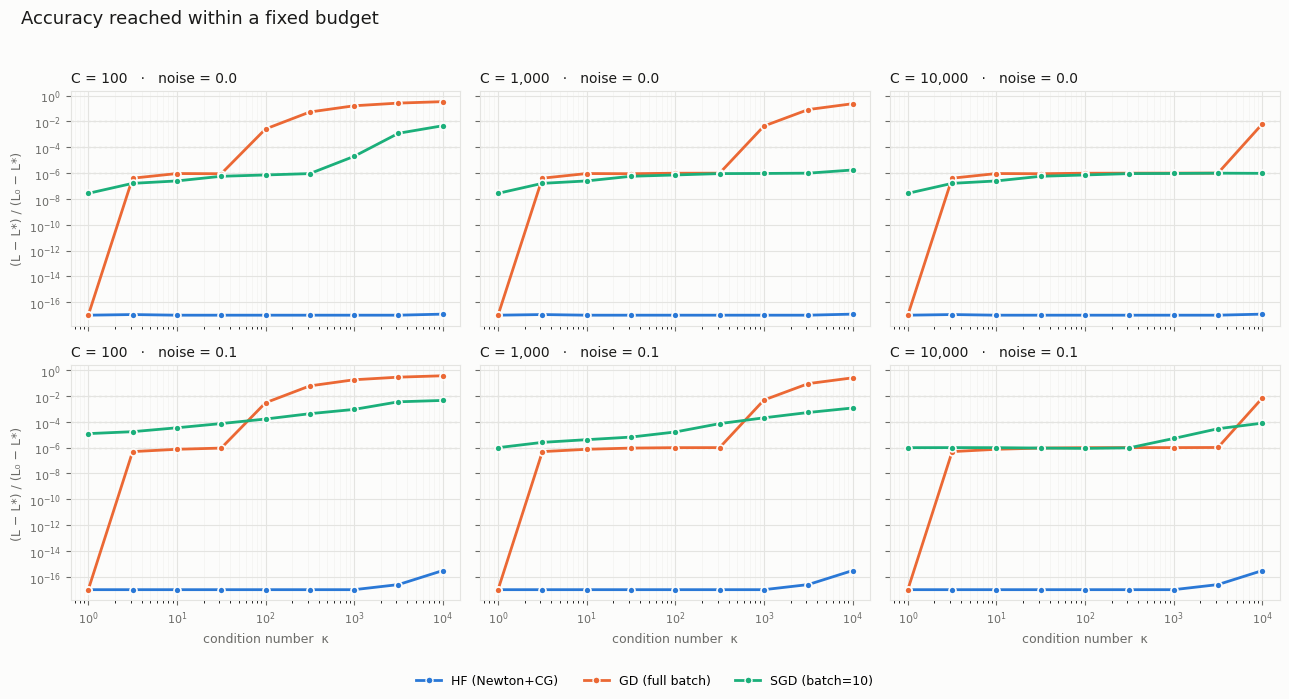

In [ ]:
fig, axes = plt.subplots(len(noises), len(cost_val), figsize=(13, 7),
                         sharex=True, sharey=True)
fig.patch.set_facecolor(surface)
for i, noise in enumerate(noises):
    for j, C in enumerate(cost_val):
        ax = axes[i, j]
        for m in order:
            ks = np.array(sorted(kappas))
            v = np.array([acc_at_budget(runs[(noise, k, m)]["trace"],
                                        runs[(noise, k, m)]["L0"],
                                        runs[(noise, k, m)]["L_star"], C) for k in ks])
            v = np.maximum(v, 1e-17)
            ax.plot(ks, v, color=color[m], linewidth=2, zorder=3)
            ax.plot(ks, v, "o", color=color[m], markersize=5,
                    markeredgecolor=surface, markeredgewidth=1.2, zorder=4)
        for eps in eps_val:
            ax.axhline(eps, color=muted, linewidth=0.8, linestyle=(0, (2, 3)), zorder=1)
        style(ax, f"C = {C:,.0f}   ·   noise = {noise}",
              xlab=(i == len(noises) - 1),
              ylab="(L − L*) / (L₀ − L*)" if j == 0 else None)

fig.legend(handles=method_handles()[:3], loc="lower center", ncol=3, frameon=False, fontsize=9)
fig.suptitle("Accuracy reached within a fixed budget", fontsize=13, color=ink, x=0.02, ha="left")
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()

## Plot C — trace mentah

Yang di-slice dua plot di atas. Garis putus horizontal = `eps_val`, vertikal = `cost_val`.

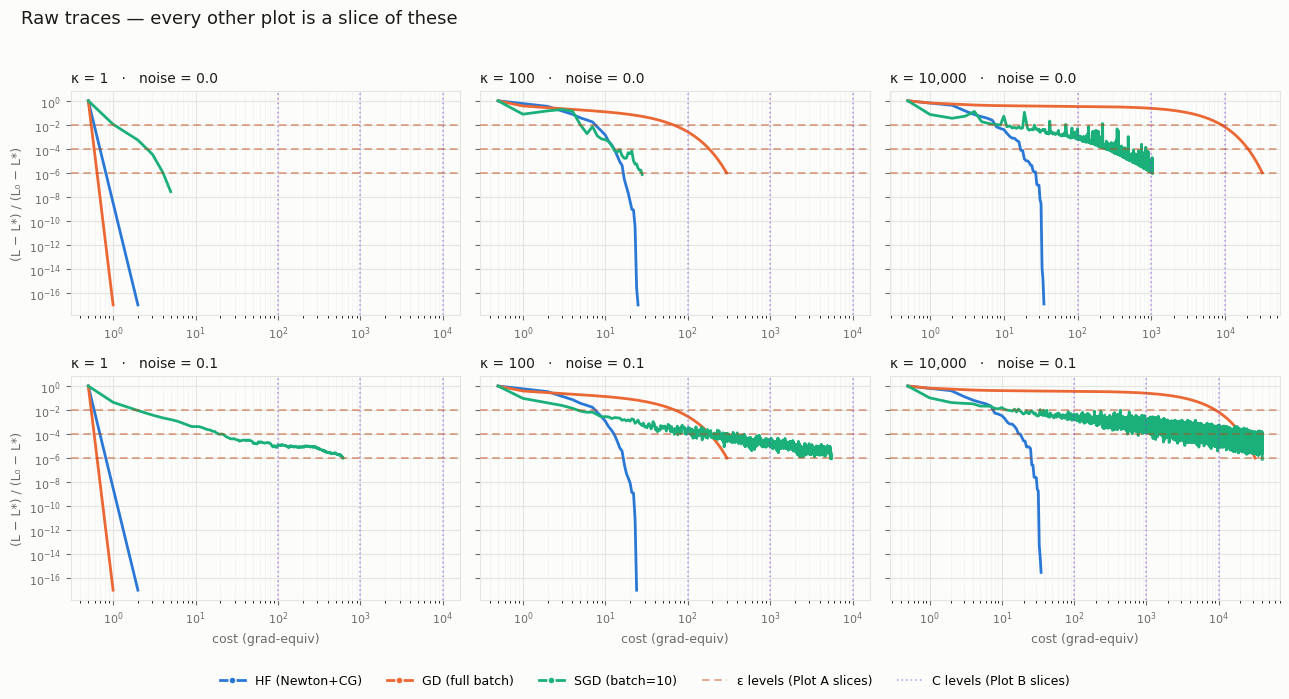

In [ ]:
show_k = [kappas[0], kappas[len(kappas)//2], kappas[-1]]

fig, axes = plt.subplots(len(noises), len(show_k), figsize=(13, 7), sharey=True)
fig.patch.set_facecolor(surface)
for i, noise in enumerate(noises):
    for j, k in enumerate(show_k):
        ax = axes[i, j]
        for m in order:
            st = runs[(noise, k, m)]
            tr = st["trace"]
            rel = np.maximum((tr[:, 1] - st["L_star"]) / (st["L0"] - st["L_star"]), 1e-17)
            ax.plot(np.maximum(tr[:, 0], 0.5), rel, color=color[m], linewidth=2, zorder=3)
        for eps in eps_val:
            ax.axhline(eps, color="#c2410c", linewidth=1.1, alpha=0.55,
                       linestyle=(0, (5, 3)), zorder=5)
        for C in cost_val:
            ax.axvline(C, color="#7c3aed", linewidth=1.1, alpha=0.55,
                       linestyle=(0, (1, 2)), zorder=5)
        style(ax, f"κ = {k:,.0f}   ·   noise = {noise}",
              xlab=(i == len(noises) - 1),
              ylab="(L − L*) / (L₀ − L*)" if j == 0 else None)
        ax.set_xlabel("cost (grad-equiv)" if i == len(noises) - 1 else "",
                      fontsize=9, color=muted)

slice_h = [plt.Line2D([], [], color="#c2410c", linewidth=1.1, alpha=0.55,
                      linestyle=(0, (5, 3)), label="ε levels (Plot A slices)"),
           plt.Line2D([], [], color="#7c3aed", linewidth=1.1, alpha=0.55,
                      linestyle=(0, (1, 2)), label="C levels (Plot B slices)")]
fig.legend(handles=method_handles()[:3] + slice_h, loc="lower center",
           ncol=5, frameon=False, fontsize=9)
fig.suptitle("Raw traces — every other plot is a slice of these",
             fontsize=13, color=ink, x=0.02, ha="left")
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()